### Compare simulations

Notebook to read in a number of `sww` files and compare (plot) stage time series and flow through cross section near Merimbula bridge.

First import important modules, set up graphics, and define two useful functions.

In [1]:
%load_ext autoreload
%autoreload 2

import project
import anuga
import pandas as pd

import numpy as np
import os
import matplotlib.pyplot as plt

#%matplotlib inline
%matplotlib ipympl

# Allow inline jshtml animations
from matplotlib import rc
rc('animation', html='jshtml')

def open_sww_file(swwfile: str, gauge_x: np.ndarray, gauge_y: np.ndarray, verbose: bool = False) -> tuple[anuga.SWW_plotter, list[int]]:
    """
    Open an SWW file and return the plotter object and gauge IDs.
    
    Args:
        swwfile: Path to the SWW file
        verbose: Whether to print debug information
        
    Returns:
        tuple containing:
            - splotter: SWW_plotter object
            - gauge_ids: list of triangle IDs for each gauge location
    """
    splotter = anuga.SWW_plotter(swwfile)

    #splotter.filename = swwfile

    starttime = splotter.starttime
    dt = pd.to_datetime(starttime, unit='s')
    if verbose:
        print(f'Start time: {dt}')

    # Convert to absolute coordinates
    xc = splotter.xc + splotter.xllcorner
    yc = splotter.yc + splotter.yllcorner

    gauge_ids = []
    for row in zip(gauge_x, gauge_y):
        tid = np.argmin((xc-row[0])**2 + (yc-row[1])**2)
        if verbose:
            print(f'Gauge at ({row[0]:.1f}, {row[1]:.1f}) assigned to triangle {tid}')
        gauge_ids.append(tid)

    return splotter, gauge_ids



Simulation directory: template
date and time: 20260210_104130


Check for sww files

In [2]:
ls -lh *.sww

-rw-r--r-- 1 steve steve 110M Feb  8 10:03 template_sept_2003_10785_weeds_20260207_163944.sww
-rw-r--r-- 1 steve steve 433M Feb  6 11:54 template_sept_2003_43200_weeds_20260128_144153.sww
-rw-r--r-- 1 steve steve 714M Feb 10 10:40 template_sept_2003_86370_weeds_20260208_150616.sww


Read specified sww files, create associated SWW_plotters, and read in gauge locations 

In [3]:
verbose = False

# Set up the sww files to compare
swwfiles = [
            #'template_sept_2003_43200_weeds_20251202_202802.sww',
            #'template_sept_2003_17156_no_exterior_tags_weeds_20251210_140515.sww',
            #'template_sept_2003_43200_weeds_20260118_114652.sww',
            'template_sept_2003_10785_weeds_20260207_163944.sww',
            'template_sept_2003_43200_weeds_20260128_144153.sww',
            'template_sept_2003_86370_weeds_20260208_150616.sww',
            ]

num_of_triangles = []
for swwfile in swwfiles:
    num_of_triangles.append(int(swwfile.split('_')[3]))

gauge_location = pd.read_csv(project.gauge_filename)
gauge_x = gauge_location['easting'].to_numpy()
gauge_y = gauge_location['northing'].to_numpy()

splotters = []
gauge_id_list = []

for n, swwfile in enumerate(swwfiles):
    splotter, gauge_ids = open_sww_file(swwfile, gauge_x, gauge_y, verbose=verbose)
    splotters.append(splotter)
    gauge_id_list.append(gauge_ids) 


# polyline at bridge
polyline = [[759205.0-10, 5912912+10],
            [759205.0+45, 5912912-30]]


polygon = [[759205.0-20, 5912912],  
           [759205.0+45, 5912912-40],
           [759205.0+55, 5912912-20],
           [759205.0+5, 5912912+40]]

Figure files for each frame will be stored in _plot
Figure files for each frame will be stored in _plot
Figure files for each frame will be stored in _plot


Plot Stage and Mesh near Merimbula Bridge

Gauge boundary at (760375.1, 5912233.1)
Gauge gauge2 at (760070.0, 5912979.0)
Gauge gauge3 at (759306.0, 5913042.0)
Gauge gauge4 at (759205.0, 5912912.0)
Gauge gauge5 at (759269.0, 5912751.0)
Gauge gauge6 at (757799.0, 5910529.0)
Gauge gauge7 at (757545.0, 5912703.0)
Gauge gauge8 at (756507.0, 5913260.0)
Triangles intersecting polygon: [189 192 200 201 205 207 209 215 218 407 464 524 555 648 651 766 767 769
 771 775 776 790 795 805 812 819 823 832 834 851 865]


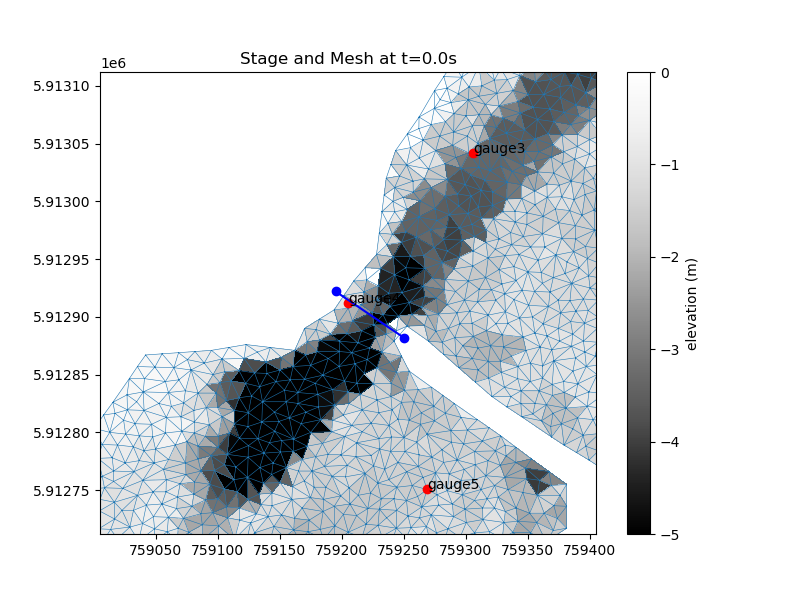

In [5]:
splotter = splotters[2]
tid = 0

fig, ax = plt.subplots(figsize=(8, 6))

lines =ax.tripcolor(splotter.triang,
              #facecolors = splotter.stage[tid,:],
              facecolors = splotter.elev[:],
              cmap='Greys_r',
              vmin= -5,
              vmax= 0.0
              )
fig.colorbar(lines, ax=ax, label='elevation (m)')

ax.triplot(splotter.triang, linewidth = 0.4)
ax.set_title(f"Stage and Mesh at t={splotter.time[tid]}s")
ax.scatter(gauge_x, gauge_y, color='red')
for i in range(8):
#for i in range(3,4):
    ax.annotate(gauge_location['name'][i], [gauge_x[i], gauge_y[i]])
    print(f'Gauge {gauge_location["name"][i]} at ({gauge_x[i]}, {gauge_y[i]})')

triangle_ids = splotter.get_triangles_inside_polygon(polygon)
print(f'Triangles intersecting polygon: {triangle_ids}')

step = 200
ax.set_xlim(759205-step, 759205.0+step)
ax.set_ylim(5912912-step, 5912912+step)

# Plot the polyline
ax.scatter([polyline[0][0], polyline[1][0]], [polyline[0][1], polyline[1][1]], color='blue')
ax.plot([polyline[0][0], polyline[1][0]], [polyline[0][1], polyline[1][1]], color='blue')

# # Plot the polygon
# ax.plot([polygon[0][0], polygon[1][0], polygon[2][0], polygon[3][0], polygon[0][0]],
#          [polygon[0][1], polygon[1][1], polygon[2][1], polygon[3][1], polygon[0][1]], color='green')

# # Plot the centroids of the triangles intersecting the polygon
# for tid in triangle_ids:
#     xcentroid = splotter.xc[tid] + splotter.xllcorner
#     ycentroid = splotter.yc[tid] + splotter.yllcorner
#     ax.scatter(xcentroid, ycentroid, color='orange')
plt.show()
#plt.clf()


### Check starttime. 

Should be 22nd Oct 2003, Australian Eastern Standard Time

In [6]:
dt_aest = pd.to_datetime(splotter.starttime, unit="s", utc=True).tz_convert(splotter.timezone)
print(dt_aest)

2003-09-22 00:00:00+10:00


Text(0.5, 1.0, 'Elevation and Mesh at t=0.0s')

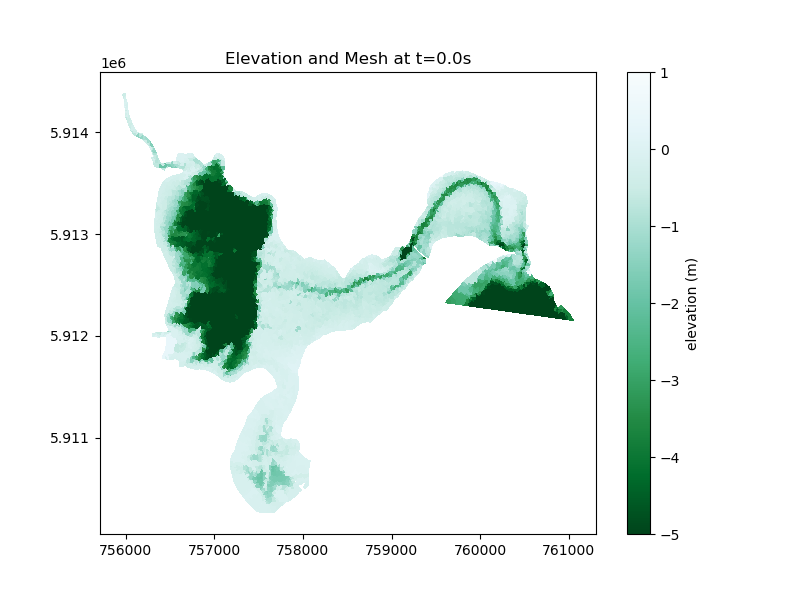

In [7]:
splotter = splotters[0]
tid = 0

fig, ax = plt.subplots(figsize=(8, 6))

lines = ax.tripcolor(splotter.triang,
              facecolors = splotter.elev[:],
              cmap='BuGn_r',
              vmin= -5,
              vmax= 1.0
              )
#ax.triplot(splotter.triang, linewidth = 0.1)
fig.colorbar(lines, ax=ax, label='elevation (m)')
ax.set_title(f"Elevation and Mesh at t={splotter.time[tid]}s")
#ax.scatter(gauge_x, gauge_y, color='red')

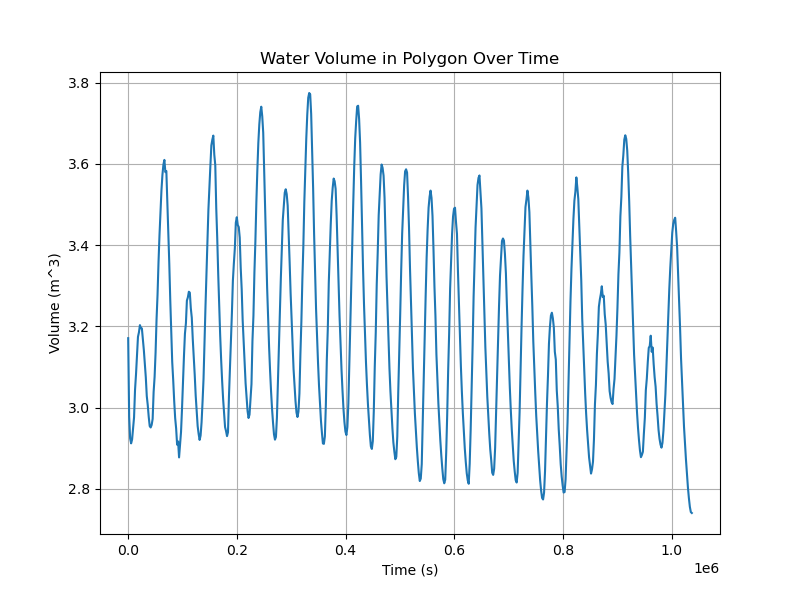

In [8]:
splotter = splotters[0]
volume = splotter.water_volume(per_unit_area=True, polygon=polygon)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(splotter.time, volume)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Volume (m^3)')
ax.set_title('Water Volume in Polygon Over Time')
ax.grid()
plt.show()

Compare flow through cross sesction

Extracting mesh intersections from line:
(759195.00, 5912922.00) - (759250.00, 5912882.00)
Reading from template_sept_2003_43200_weeds_20260128_144153.sww
    building mesh from sww file template_sept_2003_43200_weeds_20260128_144153.sww
Extracting mesh intersections from line:
(759195.00, 5912922.00) - (759250.00, 5912882.00)
Extracting mesh intersections from line:
(759195.00, 5912922.00) - (759250.00, 5912882.00)


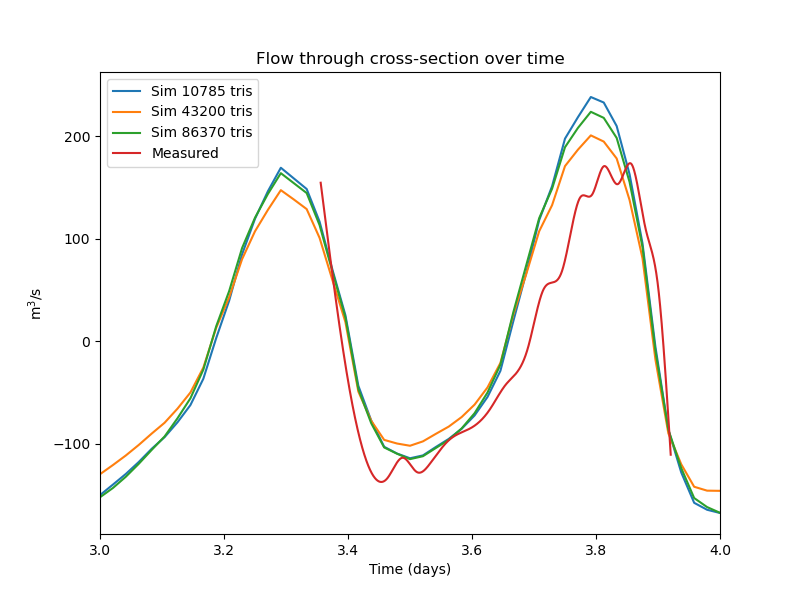

In [9]:
verbose = False

fig, ax = plt.subplots(figsize=(8, 6))

for n, splotter in enumerate(splotters):
    t, Q = splotter.get_flow_through_cross_section(polyline, verbose=True) 
    ax.plot(t/3600/24, Q, label=f'Sim {num_of_triangles[n]} tris')
    pass
ax.set_xlabel('Time (days)')
ax.set_ylabel('m$^3$/s')
ax.set_title('Flow through cross-section over time')

model_dir = '../../model_data_sept_2003'

filename = anuga.join(model_dir,'gauge4_discharge.txt')
flow = pd.read_csv(filename, header=None, sep=r"\s+")
#print(flow)

flow.columns = ['time', 'measured']
flow['time'] = flow['time'] /24.0 + 3.0 # convert time to days 25th Sept 2003 was at 3 days in the model time


ax.plot(flow['time'], flow['measured'], label='Measured')

ax.set_xlim(3,4)
ax.legend()
plt.show()

Compare stage time series at one gauge station

Simulation 0 has 577 timesteps and 10785 triangles.
Simulation 1 has 577 timesteps and 43200 triangles.
Simulation 2 has 477 timesteps and 86370 triangles.


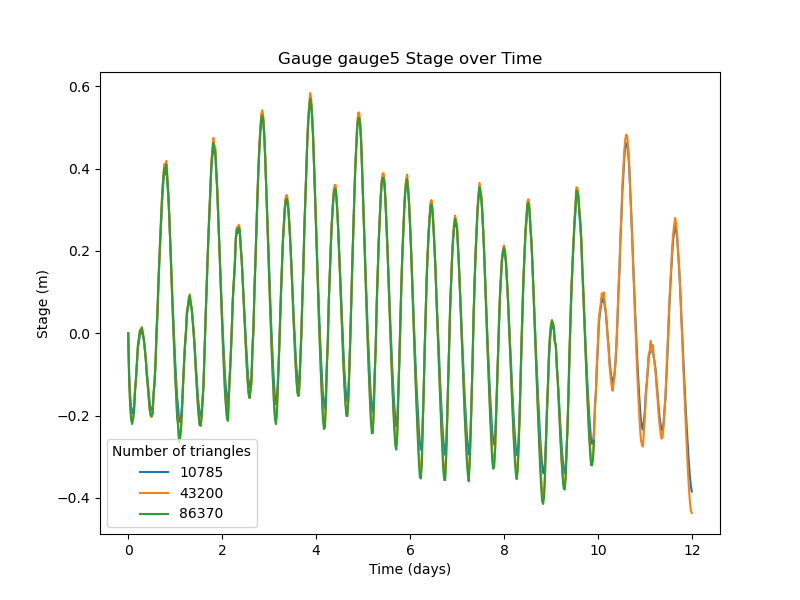

In [10]:
gid = 4  # gauge id to plot

fig, ax = plt.subplots(figsize=(8, 6))

for n,splotter in enumerate(splotters):
    print(f'Simulation {n} has {splotter.stage.shape[0]} timesteps and {splotter.stage.shape[1]} triangles.')
    ax.plot(splotter.time/3600/24, splotter.stage[:,gauge_id_list[n][gid]], label=num_of_triangles[n])

ax.legend(title='Number of triangles')
ax.set_title(f'Gauge {gauge_location["name"][gid]} Stage over Time')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Stage (m)')
plt.show()

Compare simulation results with measured stage data

Gauge 4 measured stage data is missing gauge4


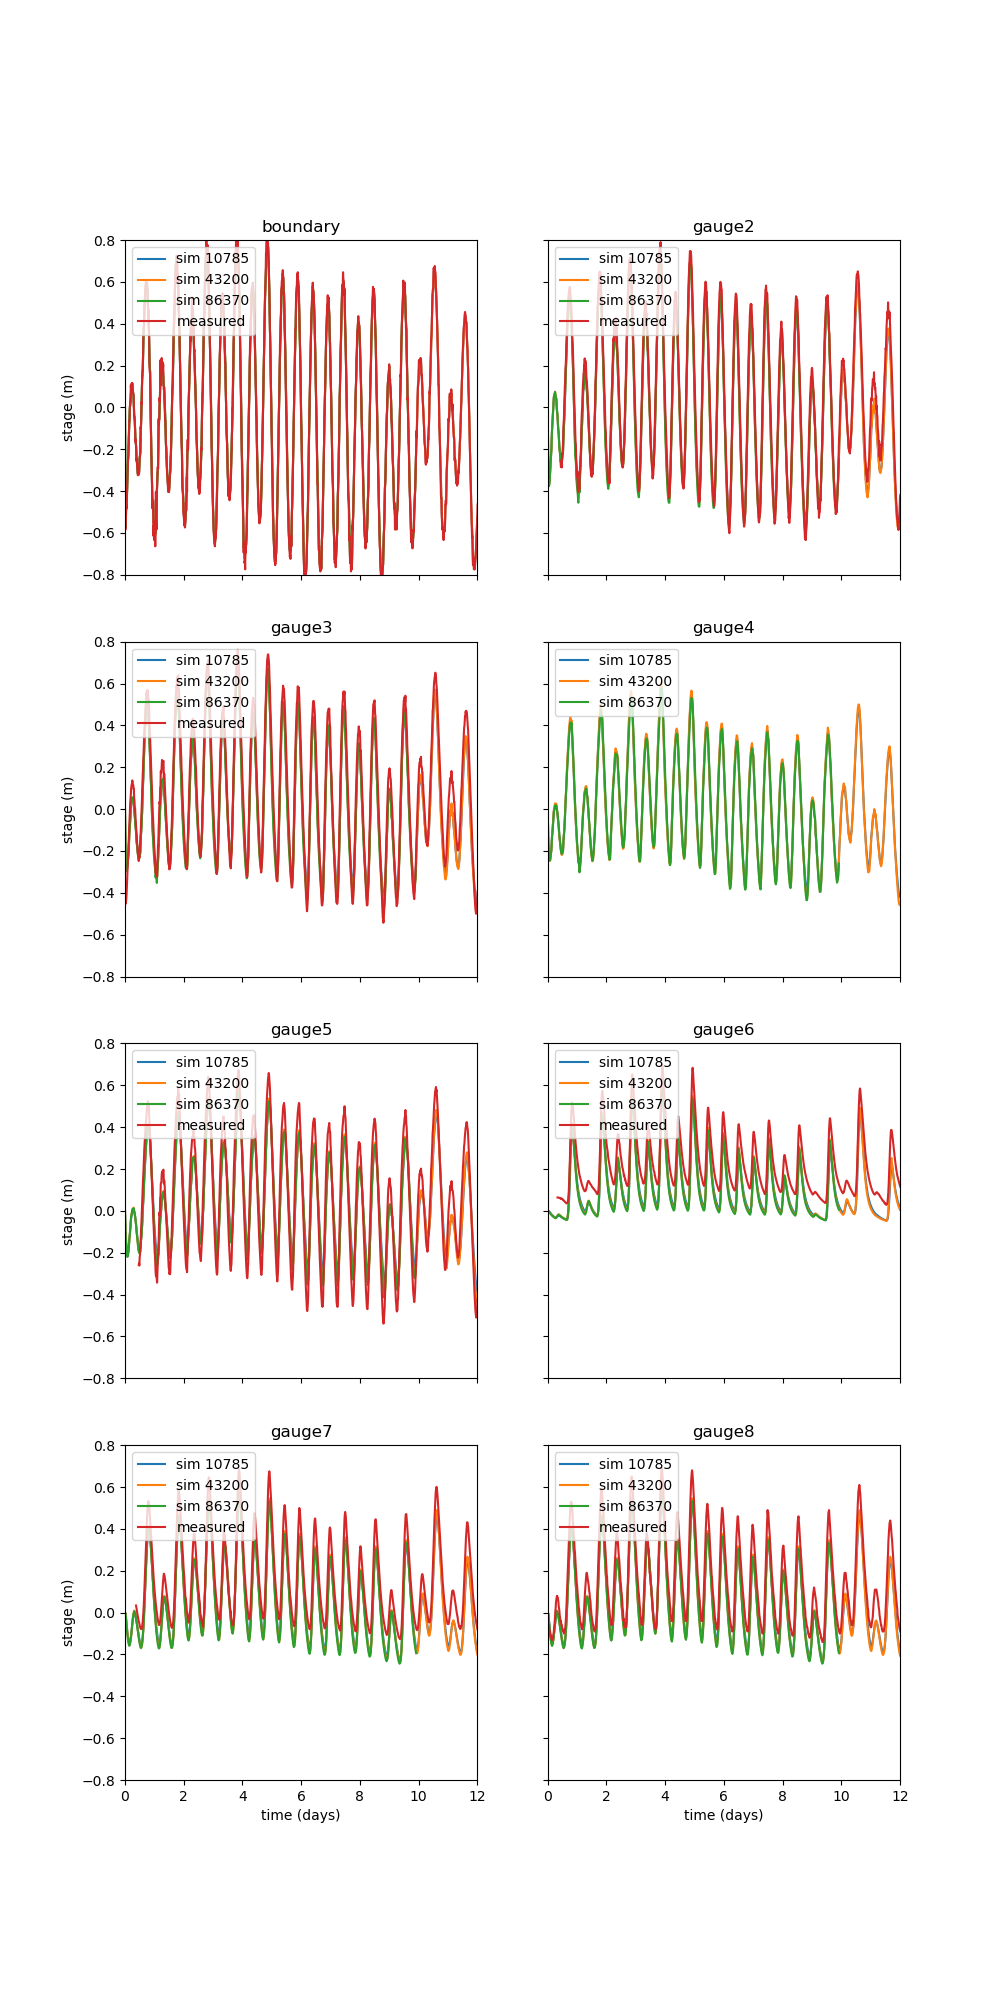

In [11]:
model_dir = '../../model_data_sept_2003'

sites = []

#for row in gauge_location.iterrows():

for index, row in gauge_location.iterrows():
    filename = anuga.join(model_dir,row['name']+'.txt')

    if row['name'] == 'gauge4':
        print(f"Gauge 4 measured stage data is missing {row['name']}")
        site = None
    else:
        site = pd.read_fwf(filename, header=None)
        site.columns = ['time', 'measured']
        site['time'] = site['time'] - 265

    sites.append(site)
        

fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8)) = plt.subplots(4, 2, figsize=(10,20), sharex=True, sharey=True)


for i, ax in enumerate([ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8]):

    ax.set_title(gauge_location['name'][i])
    for n, (splotter, gauge_ids) in enumerate(zip(splotters, gauge_id_list)): 
        #pass
        ax.plot(splotter.time/3600/24, splotter.stage[:,gauge_ids[i]], label='sim '+str(num_of_triangles[n]))
    

    if gauge_location['name'][i] == 'gauge4':
        pass
    else:
        sites[i].plot('time','measured', ax=ax, label='measured')

    ax.legend(loc='upper left')
    ax.set_xlim(0.0, 12.0)
    ax.set_ylim(-0.8, 0.8)
    ax.set_xlabel('time (days)')
    ax.set_ylabel('stage (m)')

plt.show()
plt.savefig('gauge_comparison.pdf')    


In [ ]:
# from anuga.file_conversion.sww2dem import sww2dem, sww2dem_batch

# sww2dem(swwfiles[0], name_out= 'domain2.asc', quantity='stage', verbose=True)

In [ ]:
# sww2dem_batch(swwfiles[0], quantities=['stage', 'depth'], format='asc', verbose=True)